In [ ]:
# Author: M. Riley Owens (GitHub: mrileyowens)


In [1]:
import sys

import os
import glob

import h5py

import numpy as np

from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

from grizli import utils

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from mrileyowens.stats import weighted_quantile
from mrileyowens.dja import spectra
from mrileyowens.analyze import mc, balmer_break

In [41]:
# Set common directories
home = os.getcwd()
data = f'{home}/data'
figs = f'{home}/figs'
results = f'{home}/results'

def select():

    '''
    Plot the SFHs of the 2CSFH BEAGLE models
    '''

    # Get the files containing the EW measurements of the 2CSFH fits
    files = glob.glob(f'{results}/ew/e24_f775w_dropouts_2csfh_no_lya_ews_[!m_uv_e24]*.h5')

    # Get the HDU list of the E24 catalog
    hdul = fits.open(f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits')

    # Make an empty list to contain the indices and coordinates of selected young, weak emission line sources
    #idx_e24, coords_e24 = [], []

    for p in [0.50, 0.84]:

        # Make an empty list to contain the indices and coordinates of selected young, weak emission line sources
        idx_e24, coords_e24 = [], []

        # For each EW measurements file
        for i, file in enumerate(files):

            # Open the file
            with h5py.File(file, 'r') as f:

                # For each ID in the file
                for j, id in enumerate(list(f.keys())):

                    # Get the probabilities from the posterior
                    probs = f[id]['probabilities'][:]

                    # Get the emission line EWs measured from the posterior SEDs
                    ews_o_iii, ews_h_alpha, ews_h_beta = f[id]['o_iii_ews'][:], f[id]['h_alpha_ews'][:], f[id]['h_beta_ews'][:]

                    # Calculate the 84th percentile of the [O III] + H-beta and H-alpha EWs
                    p_h_alpha = weighted_quantile(ews_h_alpha, probs, p)
                    p_o_iii_h_beta = weighted_quantile(ews_o_iii + ews_h_beta, probs, p)

                    # If the 84th percentiles of both sets of EWs are sufficiently small, continue
                    if p_h_alpha < 800 and p_o_iii_h_beta < 800:

                        # Determine the index where the object appears in the E24 catalog
                        idx = np.where(hdul[1].data['ID'] == id)

                        # Get the object's photometry necessary to measure a specific color
                        f150w = (hdul[1].data['NRC_F150W'] * u.nJy).to(u.ABmag)[idx]
                        f200w = (hdul[1].data['NRC_F200W'] * u.nJy).to(u.ABmag)[idx]
                        f277w = (hdul[1].data['NRC_F277W'] * u.nJy).to(u.ABmag)[idx]

                        # Calculate the color, which assesses the photometric slope on either side of the Balmer break at z ~ 6. 
                        # A redder color will correspond to weaker Balmer breaks, and thus young light-weighted ages
                        color = (f200w - f277w) - (f150w - f200w)

                        # If the color is sufficiently red
                        if color.value < 0.3:

                            # Add the object's coordinates to the list of E24 young, weak emission line sources
                            idx_e24.append(idx[0][0])
                            coords_e24.append([hdul[1].data['RA'][idx][0], hdul[1].data['DEC'][idx][0]])

        # Convert the coordinate list to a NumPy array
        idx_e24, coords_e24 = np.array(idx_e24, dtype=np.int64), np.array(coords_e24, dtype=np.float64)

        # Get the IDs of the young, weak emission line sources in the E24 catalog
        ids = hdul[1].data['ID'][idx_e24]

        # Save the IDs of the young, weak emission line sources in the E24 catalog
        np.savetxt(f'{results}/dja_spectra/ids_e24_young_weak_line_emitters_{str(p)[2:]}.txt', ids, fmt='%s')

def f200w():

    '''
    Plot the F200W photometry and color properties of the young, weak emission line sources
    '''

    for ids_file in glob.glob(f'{results}/dja_spectra/ids_e24_young_weak_line_emitters_*.txt'):

        print(ids_file)

        # Get the E24 IDs of the young, weak emission line sources
        #ids = np.loadtxt(f'{results}/e24_young_weak_emission_line/ids_e24.txt', dtype=str)
        ids = np.loadtxt(ids_file, dtype=str)

        # Open the HDU list of the E24 catalog
        hdul = fits.open(f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits')

        # Get the indices of the young, weak emission line sources in the E24 catalog
        idx = np.array([np.where(hdul[1].data['ID'] == id)[0][0] for id in ids], dtype=np.int64)

        # Get the F150W, F200W, and F277W photometry of the young, weak emission line sources
        f150w_ABmag = (hdul[1].data['NRC_F150W'] * u.nJy).to(u.ABmag)[idx]
        f200w_ABmag = (hdul[1].data['NRC_F200W'] * u.nJy).to(u.ABmag)[idx]
        f277w_ABmag = (hdul[1].data['NRC_F277W'] * u.nJy).to(u.ABmag)[idx]

        # Get the uncertainties on the photometry
        f150w_err_njy = (hdul[1].data['NRC_F150W_err'] * u.nJy)[idx]
        f200w_err_njy = (hdul[1].data['NRC_F200W_err'] * u.nJy)[idx]
        f277w_err_njy = (hdul[1].data['NRC_F277W_err'] * u.nJy)[idx]

        # Calculate the color, which assesses the photometric slope on either side of the Balmer break at z ~ 6. 
        # A redder color will correspond to weaker Balmer breaks, and thus young light-weighted ages
        color = ((f200w_ABmag - f277w_ABmag) - (f150w_ABmag - f200w_ABmag)).value * u.ABmag

        # Calculate the uncertainty of the photometry in magnitude space with error propagation
        f150w_err_ABmag = 2.5 / np.log(10) * (f150w_err_njy / f150w_ABmag.to(u.nJy))
        f200w_err_ABmag = 2.5 / np.log(10) * (f200w_err_njy / f200w_ABmag.to(u.nJy))
        f277w_err_ABmag = 2.5 / np.log(10) * (f277w_err_njy / f277w_ABmag.to(u.nJy))

        # Calculate the uncertainty on the color with error propagation
        color_err = np.sqrt(f150w_err_ABmag**2 + 4 * f200w_err_ABmag**2 + f277w_err_ABmag**2).value * u.ABmag
    
        # Make a new figure to plot the F200W distribution of the young, weak emission line sources
        fig, ax = plt.subplots()

        # Plot the F200W photometry distribution
        ax.hist(f200w_ABmag.value, bins=20)

        # Label the axes
        ax.set_xlabel('F200W (AB mag.) (E24)')
        ax.set_ylabel('Count')

        # Save the figure
        fig.savefig(f'{figs}/e24_young_weak_emission_line/f200w.png', bbox_inches='tight', dpi=200)

        # Make a new figure to plot the color distribution against the F200W photometry
        fig2, ax2 = plt.subplots()

        # Plot the color against the F200W photometry
        ax2.errorbar(f200w_ABmag.value, color.value, xerr=f200w_err_ABmag.value, yerr=color_err.value, c='black', marker='o', fmt='none')

        # Label the axes
        ax2.set_xlabel('F200W (AB mag.) (E24)')
        ax2.set_ylabel('(F200W - F277W) - (F150W - F200W) (AB mag.) (E24)')

        # Add a horizontal dashed line to indicate the selection's cutoff for this color
        ax2.axhline(0.3, c='red', ls='dashed')

        # Make a new figure to plot the uncertainty of the color against the F200W photometry
        fig3, ax3 = plt.subplots()

        # Plot the uncertainty of the color against the F200W photometry
        ax3.scatter(f200w_ABmag.value, color_err.value, c='black', marker='o')

        # Label the axes
        ax3.set_xlabel('F200W (AB mag.) (E24)')
        ax3.set_ylabel('$\Delta$((F200W - F277W) - (F150W - F200W)) (AB mag.) (E24)')

        # Make a new figure to plot the fractional uncertainty relative to the selection's color cutoff against the F200W photometry
        fig4, ax4 = plt.subplots()

        # Plot the fractional uncertainty relative to the selection's color cutoff against the F200W photometry
        ax4.scatter(f200w_ABmag.value, np.abs((color - 0.3 * u.ABmag).value) / color_err.value, c='black', marker='o')

        # Label the axes
        ax4.set_xlabel('F200W (AB mag.) (E24)')
        ax4.set_ylabel('|(F200W - F277W) - (F150W - F200W) -  0.3| \n / $\Delta$((F200W - F277W) - (F150W - F200W)) (E24)')

def download_dja_spectra():

    '''
    Download the prism spectra of any coordinate matches to the E24 F775W dropout galaxy catalog
    '''

    # -------------------------------------------------------------------------------
    # Get the coordinates of the E24 catalog
    # -------------------------------------------------------------------------------

    # Get the E24 IDs of the young, weak emission line sources
    #ids_e24 = np.loadtxt(f'{results}/e24_young_weak_emission_line/ids_e24.txt', dtype=str)

    # Open the HDU list of the E24 catalog
    hdul_e24 = fits.open(f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits')

    ids_e24 = hdul_e24[1].data['ID']

    # Get the indices of the young, weak emission line sources in the E24 catalog
    #idx_e24 = np.array([np.where(hdul_e24[1].data['ID'] == id)[0][0] for id in ids_e24], dtype=np.int64)

    # Get the coordinates of the sources as a SkyCoord object
    #coords_e24 = SkyCoord(ra=hdul_e24[1].data['RA'][idx_e24] * u.deg, dec=hdul_e24[1].data['DEC'][idx_e24] * u.deg)
    coords_e24 = SkyCoord(ra=hdul_e24[1].data['RA'] * u.deg, dec=hdul_e24[1].data['DEC'] * u.deg)

    # Download the prism spectra of any coordinate matches in the DJA spectroscopic catalog
    matches = spectra(ids_e24, coords_e24, match_strs=['prism'], dir=f'{data}/dja_spectra')

    #ids_e24 = np.loadtxt(f'{results}/dja_spectra/ids_e24.txt', dtype=str)
    #ids_e24 = hdul_e24[1].data['ID']

    #ids_e24 = ids_e24[d2d < 0.1 * u.arcsec]

    np.savetxt(f'{results}/dja_spectra/ids_e24.txt', matches, delimiter=',', fmt='%s')

def plot():

    '''
    Plot the prism spectra of sources in the E24 catalog with matches in the DJA spectroscopic catalog
    '''

    # Get the prism spectra
    files = glob.glob(f'{data}/dja_spectra/*.spec.fits')

    # Open the DJA spectroscopic catalog
    tab = utils.read_catalog(f'../mrileyowens/dja_msaexp_emission_lines_v4.4.csv', format='csv')

    # For the FITS file of each prism spectrum
    for i, file in enumerate(files):

        # Get the HDU list
        hdul = fits.open(file)

        # Get the wavelength, flux density, and flux density uncertainty of the spectrum
        w_um = hdul[1].data['wave'] * u.um
        f_ujy = hdul[1].data['flux'] * u.uJy
        f_err_ujy = hdul[1].data['err'] * u.uJy

        # Get the best redshift of the source
        z = tab['z_best'][tab['file'] == os.path.basename(file)].data[0]

        # Make a new figure of the prism spectrum
        fig, ax = plt.subplots()

        # Make a secondary x-axis on the top of the figure to show the rest wavelength
        ax_rest = ax.secondary_xaxis('top', functions=(lambda w: w / (1 + z), lambda w: w * (1 + z)))

        # Plot the spectrum
        ax.plot(w_um, f_ujy, ds='steps-mid', c='black')

        # Plot the uncertainty on the spectrum as a shaded region
        ax.fill_between(w_um, f_ujy - f_err_ujy, f_ujy + f_err_ujy, step='mid', alpha=0.2, color='black')

        # Label the axes
        ax.set_xlabel('Observed wavelength ($\mu$m)')
        ax_rest.set_xlabel('Rest wavelength ($\mu$m)')
        ax.set_ylabel('Flux density (uJy)')

        # Set the y-axis limits
        ax.set_ylim(bottom=0, top=np.min([np.nanmax(f_ujy.value), 20 * np.median(np.abs(f_ujy[~np.isnan(f_ujy)]).value)]))

def sample():

    '''
    Create Monte Carlo-sampled spectra of the prism spectra of sources in the E24 catalog
    '''

    # Get the prism spectra
    files = glob.glob(f'{data}/dja_spectra/*.spec.fits')

    # Randomly sample the spectra according to their uncertainties and save the perturbed spectra in an HDF5 file
    mc([fits.open(file)[1].data['wave'] * u.um for file in files], [fits.open(file)[1].data['flux'] * u.uJy for file in files], [fits.open(file)[1].data['err'] * u.uJy for file in files], f'{results}/dja_spectra/mc.h5', N=1000, files=files, overwrite=True, verbose=True)

def balmer():

    '''
    Measure the Balmer breaks of the Monte Carlo-sampled prism spectra of the E24 catalog
    '''

    # Get the prism spectra
    files = glob.glob(f'{data}/dja_spectra/*.spec.fits')

    # Get the DJA spectroscopic catalog
    tab = utils.read_catalog(f'../mrileyowens/dja_msaexp_emission_lines_v4.4.csv', format='csv')

    # Get the best redshifts of the spectra
    z = tab['z_best'][[np.where(tab['file'] == os.path.basename(file))[0][0] for file in files]].data

    # Measure the Balmer breaks of the perturbed spectra and save the results
    balmer_break(f'{results}/dja_spectra/mc.h5', f'{results}/dja_spectra/bb.h5', frame='observed', z=z, overwrite=True, verbose=True)

def ews():

    lines_dict = {
        'o_iii+h-beta' : [r'[O III] 4959, 5007 $\mathrm{\AA}$', [[0.475,0.51]], [[0.42,0.47],[0.52,0.57]]],
        'h_alpha' : [r'H$\alpha$', [[0.645,0.665]], [[0.6,0.64],[0.67,0.7]]] 
    }

    files = glob.glob(f'{data}/dja_young_weak_emission_line_spectra/*.spec.fits')

    tab = utils.read_catalog(f'{data}/dja_msaexp_emission_lines_v4.4.csv', format='csv')

    with h5py.File(f'{results}/e24_young_weak_emission_line_ews.h5', 'w') as f:

        for i, file in enumerate(files):

            hdul = fits.open(file)

            w_um = hdul[1].data['wave'] * u.um
            f_ujy = hdul[1].data['flux'] * u.uJy
            f_err_ujy = hdul[1].data['err'] * u.uJy

            z = tab['z_best'][tab['file'] == os.path.basename(file)].data[0]

            w_rest_um = w_um / (1 + z)

            f_mc_ujy = np.random.normal(loc=f_ujy, scale=f_err_ujy, size=(10, len(f_ujy)))

            #bb_ratios = []

            print(f'{os.path.basename(file)}:\t', end='')

            for line in lines_dict:

                ews = []

                mask_cont = np.zeros(len(w_rest_um), dtype=bool)
                mask_line = np.zeros(len(w_rest_um), dtype=bool)

                for band in lines_dict[line][2]:

                    mask_cont = mask_cont | ((w_rest_um.value > band[0]) & (w_rest_um.value < band[1]))

                for band in lines_dict[line][1]:

                    mask_line = mask_line | ((w_rest_um.value > band[0]) & (w_rest_um.value < band[1]))

                n = 0

                while n != (len(f_mc_ujy) - 1):

                    f_cont = np.median(f_mc_ujy[n][mask_cont])

                    #print(f_mc_ujy[n][mask_cont], f_cont, w_rest_um[mask_line])

                    ew = np.abs(np.trapz(1 - f_mc_ujy[n][mask_line] / f_cont, w_rest_um[mask_line]))

                    ews.append(ew.value)

                    #bb_ratio = np.interp(0.42 * (1 + z) * u.um, w_um, f_mc_ujy[n]) / np.interp(0.35 * (1 + z) * u.um, w_um, f_mc_ujy[n])

                    '''
                    if np.isnan(bb_ratio):

                        f_mc_ujy[n] = np.random.normal(loc=f_ujy, scale=f_err_ujy, size=len(f_ujy))

                        continue
                    '''

                    #bb_ratios.append(bb_ratio)

                    n += 1

                #print(ews)

                ews = np.array(ews, dtype=np.float64) * 1e4

                print(f'{line}: {np.median(ews):.0f}_-{(np.median(ews) - np.percentile(ews, 16)):.0f}^+{(np.percentile(ews, 84) - np.median(ews)):.0f}\t', end='')

            print('')

def snr():

    # Get the prism spectra
    files = glob.glob(f'{data}/dja_spectra/*.spec.fits')

    # Open the DJA spectroscopic catalog
    tab = utils.read_catalog(f'../mrileyowens/dja_msaexp_emission_lines_v4.4.csv', format='csv')

    hdul_e24 = fits.open(f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits')
    ids_e24 = hdul_e24[1].data['ID']

    matches = np.loadtxt(f'{results}/dja_spectra/ids_e24.txt', delimiter=',', dtype=str)
    #print(matches[:,1])

    # Make a new figure to compare several quantities against the continuum SNR
    fig, ax = plt.subplots(4,1, figsize=(10,10), sharex=True)

    # Open the HDF5 file containing the Balmer break measurements
    with h5py.File(f'{results}/dja_spectra/bb.h5', 'r') as hdf5:

        # For the FITS file of each prism spectrum
        for i, file in enumerate(files):

            #print(matches[np.where(matches[:,1] == os.path.basename(file))][0])
            idx_e24 = np.where(ids_e24 == matches[np.where(matches[:,1] == os.path.basename(file))][0][0])
            print(idx_e24)

            # Get the HDU list
            hdul = fits.open(file)

            # Get the wavelength, flux density, and flux density uncertainty of the spectrum
            w_um = hdul[1].data['wave'] * u.um
            f_ujy = hdul[1].data['flux'] * u.uJy
            f_err_ujy = hdul[1].data['err'] * u.uJy

            # Get the best redshift of the source
            z = tab['z_best'][tab['file'] == os.path.basename(file)].data[0]

            # Calculate the rest wavelengths of the spectrum
            w_rest_um = w_um / (1 + z)

            # Calculate the median SNR between 0.32 and 0.35 microns in the rest frame as a rough estimate of the continuum SNR
            snr = np.median((f_ujy.value / f_err_ujy.value)[(w_rest_um.value > 0.32) & (w_rest_um.value < 0.35)])

            # Get the Balmer break measurements of the spectrum
            bb = hdf5[os.path.basename(file)]['Balmer breaks'][:]

            # Plot the continuum SNR of the spectrum against one of several Balmer break-related quantities
            ax[0].errorbar(snr, np.median(bb), yerr=[[np.median(bb) - np.percentile(bb, 16)], [np.percentile(bb, 84) - np.median(bb)]], c='black', marker='o')
            ax[1].scatter(snr, np.percentile(bb, 84) - np.percentile(bb, 16), c='black')
            ax[2].scatter(snr, np.abs((np.percentile(bb, 84) - np.percentile(bb, 16)) / np.median(bb)), c='black')
            ax[3].errorbar(snr, (hdul_e24[1].data['NRC_F200W'][idx_e24] * u.nJy).to(u.ABmag).value, yerr=(2.5 / np.log(10) * (hdul_e24[1].data['NRC_F200W_err'] / hdul_e24[1].data['NRC_F200W']))[idx_e24], c='black', marker='o')

    # Label the axes of the panels
    ax[0].set_ylabel('Balmer break\n($f_\\nu$(4200 $\mathrm{\AA}$) / $f_\\nu$(3500 $\mathrm{\AA}$))')
    ax[1].set_ylabel('P$_{84}$(BB) - P$_{16}$(BB)')
    ax[2].set_ylabel('|(P$_{84}$(BB) - P$_{16}$(BB)) / P$_{50}$(BB)|')
    ax[3].set_ylabel('F200W (AB mag.) (E24)')
    ax[3].set_xlabel('Continuum SNR')

    # Add a horizontal dashed line to the third panel representing a 20% fractional uncertainty on the Balmer break measurement
    ax[2].axhline(0.2, c='red', ls='dashed')

    # Set the y-axis of the last two panels as logarithmic
    ax[1].set_yscale('log')
    ax[2].set_yscale('log')

<>:153: SyntaxWarning: invalid escape sequence '\D'
<>:163: SyntaxWarning: invalid escape sequence '\D'
<>:239: SyntaxWarning: invalid escape sequence '\m'
<>:240: SyntaxWarning: invalid escape sequence '\m'
<>:410: SyntaxWarning: invalid escape sequence '\m'
<>:153: SyntaxWarning: invalid escape sequence '\D'
<>:163: SyntaxWarning: invalid escape sequence '\D'
<>:239: SyntaxWarning: invalid escape sequence '\m'
<>:240: SyntaxWarning: invalid escape sequence '\m'
<>:410: SyntaxWarning: invalid escape sequence '\m'
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_48474/2448998481.py:153: SyntaxWarning: invalid escape sequence '\D'
  ax3.set_ylabel('$\Delta$((F200W - F277W) - (F150W - F200W)) (AB mag.) (E24)')
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_48474/2448998481.py:163: SyntaxWarning: invalid escape sequence '\D'
  ax4.set_ylabel('|(F200W - F277W) - (F150W - F200W) -  0.3| \n / $\Delta$((F200W - F277W) - (F150W - F200W)) (E24)')
/var/folders/md/b3rxd7_x6z

In [37]:
select()

/Users/a15136/Documents/research/jades_ew_dist/results/dja_spectra/ids_e24_young_weak_line_emitters_5.txt
/Users/a15136/Documents/research/jades_ew_dist/results/dja_spectra/ids_e24_young_weak_line_emitters_84.txt


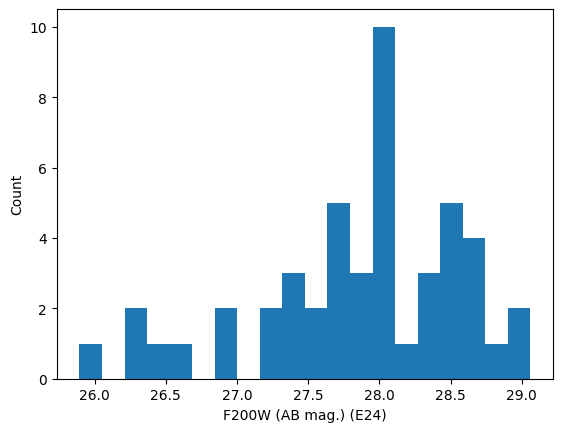

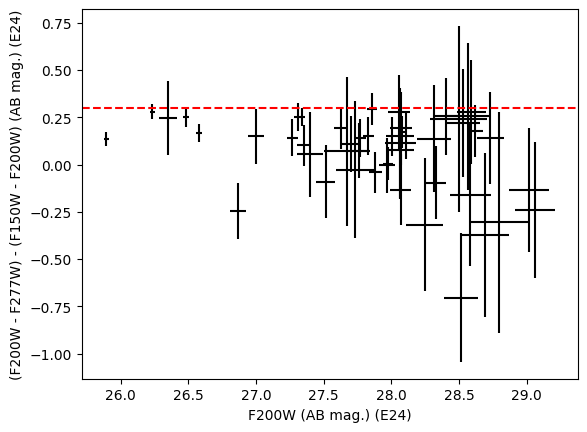

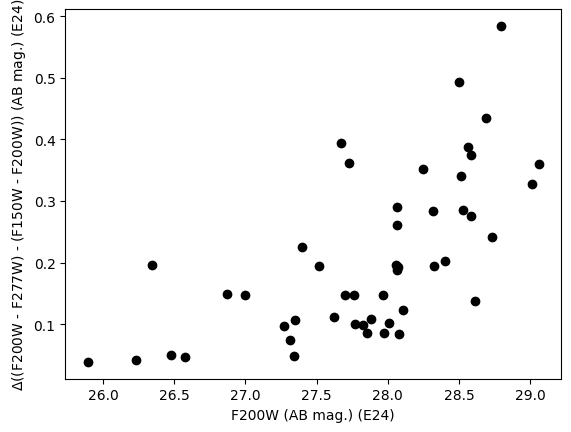

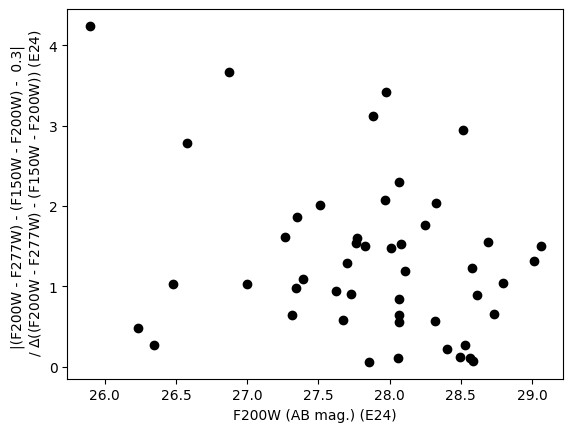

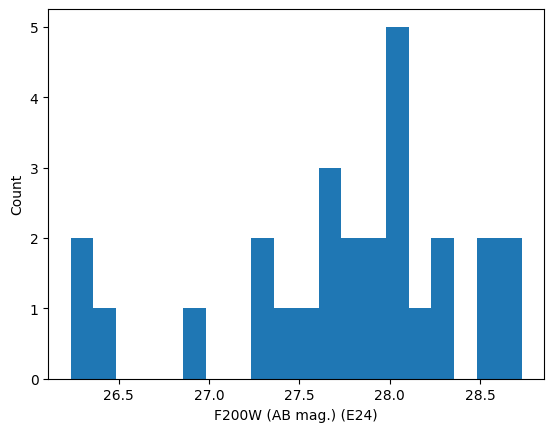

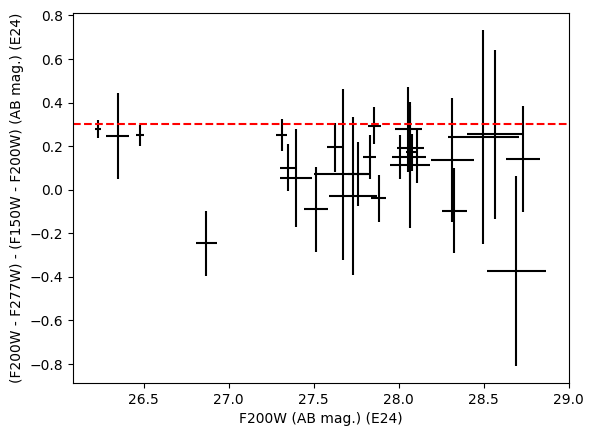

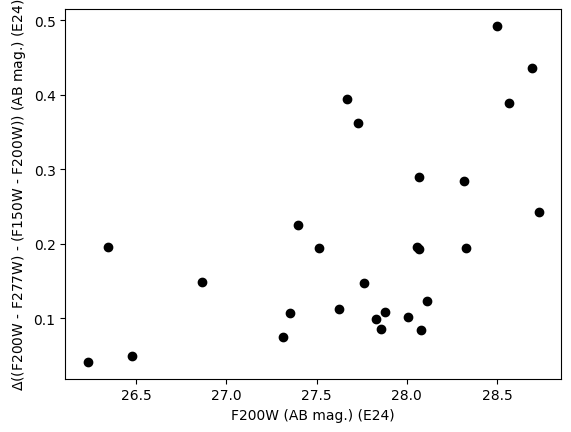

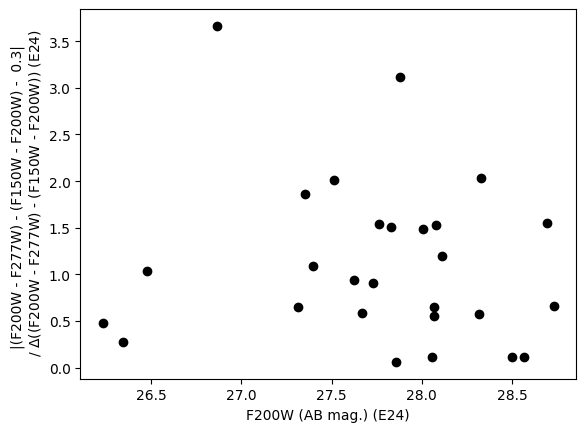

In [42]:
f200w()

In [ ]:
# Should open up and look at some of the fainter SEDs / prism spectra
# Look at JADES / DJA catalog to see what has actually been observed spectroscopically
# Think about how to extend z = 6 young, weak emission line sources to z = 7 - 8; based on recent SFHs, etc.
# Literature searches on UV slopes, SF main sequences, ionizing photon production efficiencies, etc
# Tony Paul, Bagley papers

In [3]:
download_dja_spectra()

[['85267_GOODSS', 'jades-gds05-v4_prism-clear_1286_30085267.spec.fits'], ['143240_GOODSS', 'jades-gds-wide3-v4_prism-clear_1180_30143240.spec.fits'], ['81229_GOODSS', 'gds-deep-v4_prism-clear_1210_15125.spec.fits'], ['128655_GOODSS', 'jades-gds-wide-v4_prism-clear_1180_13638.spec.fits'], ['86319_GOODSS', 'jades-gds-wide2-v4_prism-clear_1180_9698.spec.fits'], ['139415_GOODSS', 'jades-gds-wide-v4_prism-clear_1180_13887.spec.fits'], ['85942_GOODSS', 'jades-gds-wide-v4_prism-clear_1180_9696.spec.fits'], ['92610_GOODSS', 'jades-gds-wide2-v4_prism-clear_1180_13664.spec.fits'], ['148179_GOODSS', 'jades-gds08-v4_prism-clear_1286_30148179.spec.fits'], ['132992_GOODSS', 'jades-gds-wide-v4_prism-clear_1180_58850.spec.fits'], ['91255_GOODSS', 'gds-egami-ddt-v4_prism-clear_6541_114613.spec.fits'], ['141841_GOODSS', 'gds-deep-v4_prism-clear_1210_9880.spec.fits'], ['139245_GOODSS', 'jades-gds-wide-v4_prism-clear_1180_9860.spec.fits'], ['70114_GOODSS', 'jades-gds1-v4_prism-clear_1286_32880.spec.fits']

In [ ]:
plot()

In [ ]:
sample()

In [ ]:
balmer()

In [ ]:
ews()

(array([70]),)
(array([220]),)
(array([3]),)
(array([268]),)
(array([92]),)
(array([37]),)
(array([189]),)
(array([158]),)
(array([113]),)
(array([202]),)
(array([269]),)
(array([274]),)
(array([213]),)
(array([39]),)
(array([211]),)
(array([99]),)
(array([106]),)
(array([153]),)
(array([180]),)
(array([261]),)
(array([139]),)
(array([172]),)
(array([236]),)
(array([134]),)
(array([27]),)
(array([5]),)
(array([159]),)
(array([171]),)
(array([124]),)
(array([1]),)
(array([191]),)
(array([175]),)
(array([157]),)
(array([160]),)
(array([142]),)
(array([95]),)
(array([148]),)
(array([68]),)
(array([98]),)


/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(array([101]),)
(array([71]),)
(array([165]),)
(array([44]),)
(array([230]),)
(array([277]),)
(array([111]),)
(array([155]),)
(array([221]),)
(array([150]),)
(array([36]),)
(array([123]),)


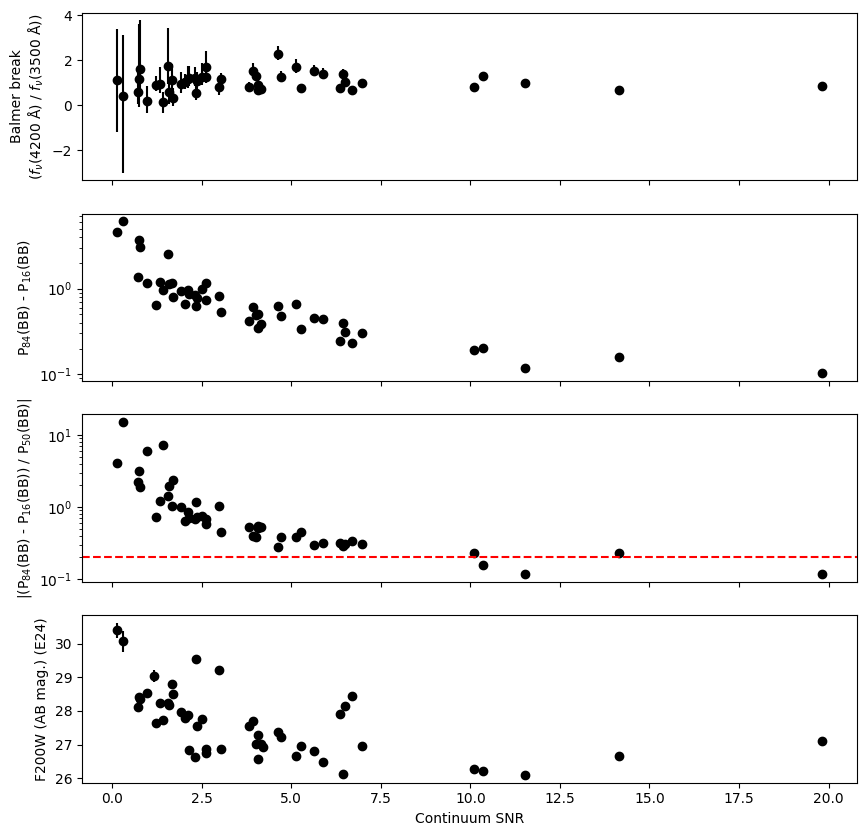

In [29]:
snr()